<a href="https://colab.research.google.com/github/archangel2006/Quantinel/blob/main/04_quantum_similarity_qsvc%20(34%25).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Imports**

In [64]:
# %pip install -U \
# qiskit \
# qiskit-machine-learning \
# qiskit-aer \
# pylatexenc \
# matplotlib


In [65]:
import qiskit
import qiskit_machine_learning
import matplotlib
import pylatexenc

print("Qiskit:", qiskit.__version__)
print("QML:", qiskit_machine_learning.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Pylatexenc:", pylatexenc.__version__)

Qiskit: 2.4.2
QML: 0.9.0
Matplotlib: 3.11.0
Pylatexenc: 2.10


In [66]:
print(qiskit.__version__)
print(qiskit.__file__)

2.4.2
/usr/local/lib/python3.12/dist-packages/qiskit/__init__.py


In [67]:
#!pip install qiskit
#!pip install qiskit-machine-learning -q
#!pip install qiskit-aer
#!pip install qiskit-algorithms
#!pip install pylatexenc
#!pip install -q pylatexenc

print("done")

done


In [68]:
import qiskit
import pylatexenc

print(qiskit.__version__)
print(pylatexenc.__version__)

from qiskit.utils.optionals import HAS_PYLATEX
print(bool(HAS_PYLATEX))

2.4.2
2.10
True


In [69]:
!pip list | grep -i qi.skit

In [70]:
from qiskit.utils.optionals import HAS_PYLATEX
bool(HAS_PYLATEX)

True

In [71]:
import pandas as pd
import numpy as np
import joblib

from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import pylatexenc

from qiskit.circuit.library import ZZFeatureMap

from qiskit_machine_learning.kernels import FidelityQuantumKernel

from qiskit_machine_learning.algorithms import QSVC

**Load Saved Artifacts**

In [72]:
preprocessor = joblib.load("similarity_preprocessor.pkl")

pca = joblib.load("similarity_pca.pkl")

x_train_pca = joblib.load("x_train_pca.pkl")

y_family = joblib.load("y_family.pkl")

print(x_train_pca.shape)
print(len(y_family))

(35065, 20)
35065


In [73]:
test = pd.read_csv("KDDTest.csv")

print(test.shape)

(22544, 43)


In [74]:
unseen_attacks = [
    "apache2",
    "httptunnel",
    "mailbomb",
    "mscan",
    "named",
    "processtable",
    "ps",
    "saint",
    "sendmail",
    "snmpgetattack",
    "snmpguess",
    "sqlattack",
    "udpstorm",
    "worm",
    "xlock",
    "xsnoop",
    "xterm"
]

In [75]:
unseen_mapping = {
    "apache2":"dos",
    "mailbomb":"dos",
    "processtable":"dos",
    "udpstorm":"dos",

    "mscan":"probe",
    "saint":"probe",

    "httptunnel":"r2l",
    "named":"r2l",
    "sendmail":"r2l",
    "snmpgetattack":"r2l",
    "snmpguess":"r2l",
    "xlock":"r2l",
    "xsnoop":"r2l",

    "ps":"u2r",
    "sqlattack":"u2r",
    "xterm":"u2r"
}

# **Quantum Dataset Reduction**

In [76]:
family_df = pd.DataFrame(x_train_pca)

family_df["family"] = y_family

In [77]:
# dos_sample = family_df[
#     family_df["family"]=="dos"].sample(100, random_state=42
# )

# probe_sample = family_df[family_df["family"]=="probe"].sample(100, random_state=42)

# r2l_sample = family_df[family_df["family"]=="r2l"].sample(100, random_state=42)

# u2r_sample = family_df[family_df["family"]=="u2r"]

In [78]:
family_df = pd.DataFrame(x_train_pca)
family_df["family"] = y_family

quantum_train = family_df.copy()

In [79]:
quantum_train = pd.concat([
    dos_sample,
    probe_sample,
    r2l_sample,
    u2r_sample
])

quantum_train.shape

(315, 21)

# Quantum PCA

In [80]:
# quantum_pca = PCA(
#     n_components=4,
#     random_state=42
# )

# x_quantum = quantum_pca.fit_transform(
#     quantum_train.drop(
#         columns=["family"]
#     )
# )

# y_quantum = quantum_train["family"]

In [81]:
quantum_pca = PCA(n_components=8, random_state=42)
x_quantum = quantum_pca.fit_transform(
    quantum_train.drop(columns=["family"])
)
y_quantum = quantum_train["family"]

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(quantum_train.drop(columns=["family"]))
x_quantum = quantum_pca.fit_transform(x_scaled)

In [83]:
print("Quantum PCA Shape:", x_quantum.shape)

explained = quantum_pca.explained_variance_ratio_

for i, val in enumerate(explained, start=1):
    print(f"PC{i}: {val:.4f}")

print(
    "\nTotal Variance Retained:",
    explained.sum()
)

Quantum PCA Shape: (315, 8)
PC1: 0.2914
PC2: 0.2299
PC3: 0.1124
PC4: 0.0850
PC5: 0.0689
PC6: 0.0548
PC7: 0.0485
PC8: 0.0423

Total Variance Retained: 0.9332204700774561


In [84]:
print(pd.Series(y_quantum).value_counts())

family
dos      100
probe    100
r2l      100
u2r       15
Name: count, dtype: int64


In [85]:
x_quantum.shape

(315, 8)

In [86]:
from collections import Counter

# verifying class balance
print(Counter(y_quantum))

Counter({'dos': 100, 'probe': 100, 'r2l': 100, 'u2r': 15})


### **Classical SVC Baseline on Quantum Dataset**

In [87]:
from sklearn.svm import SVC

svc = SVC(
    kernel="rbf"
)

svc.fit(
    x_quantum,
    y_quantum
)

SVC()

In [88]:
svc_result = svc.predict(x_quantum)

print("SVC training accuracy:",
      accuracy_score(y_quantum, svc_result))

SVC training accuracy: 0.4253968253968254


# Quantum Feature Map

/tmp/ipykernel_1456/1276183719.py:1: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=4, reps=2)


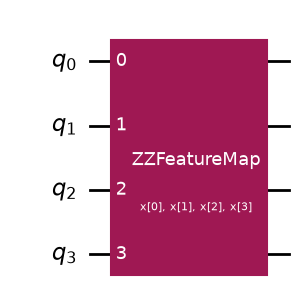

In [89]:
feature_map = ZZFeatureMap(feature_dimension=4, reps=2)
feature_map.draw("mpl")



In [90]:
feature_map = ZZFeatureMap(feature_dimension=4, reps=2)

fig = feature_map.decompose().draw("mpl")

fig.savefig(
    "ZZFeatureMap_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)


from google.colab import files
files.download("ZZFeatureMap_300dpi.png")

/tmp/ipykernel_1456/3877790677.py:1: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=4, reps=2)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

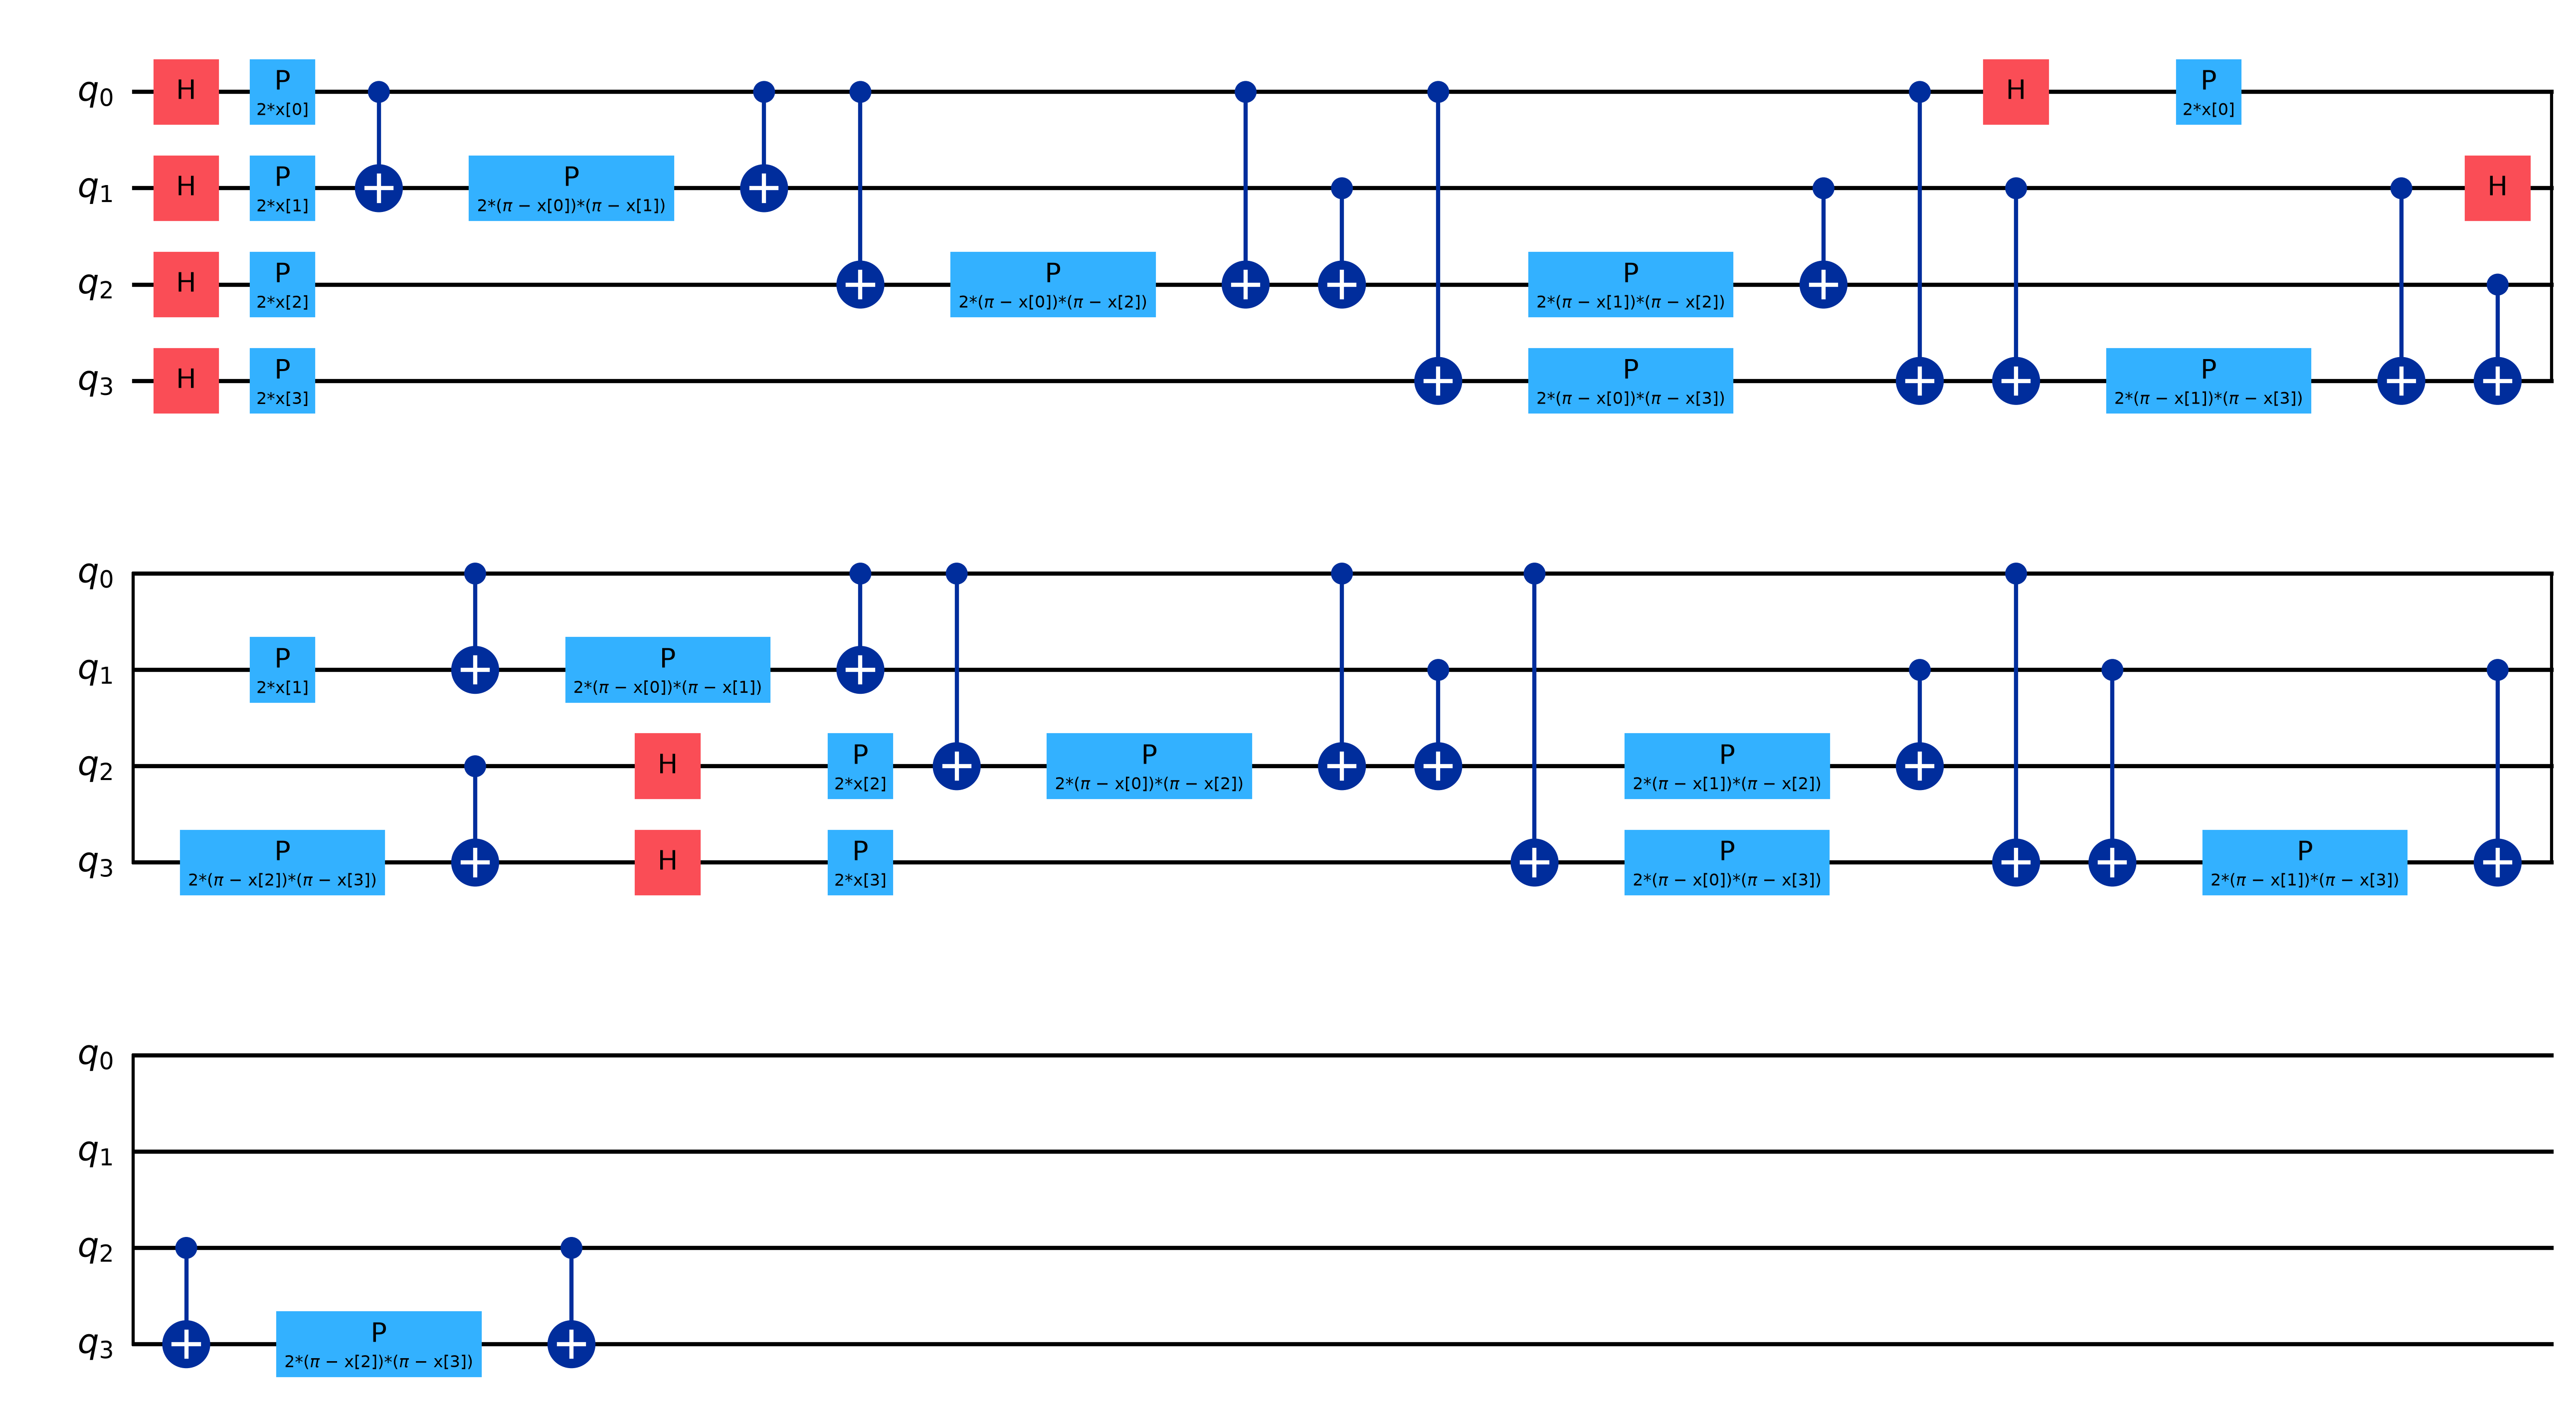

# **Fidelity Quantum Kernel**

In [91]:
quantum_kernel = (
    FidelityQuantumKernel(
        feature_map=feature_map
    )
)

# **Quantum Support Vector Classification**

Advanced machine learning algorithm that adapts **classical Support Vector Classification (SVC)** algorithms to run on quantum computers.

- Instead of using classical equations for data evaluation, it uses **quantum kernels and circuits** to analyze and classify **complex high-dimensional datasets**

In [92]:
qsvc = QSVC(quantum_kernel=quantum_kernel)

qsvc.fit(x_quantum, y_quantum)

QSVC(C=1.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
     decision_function_shape='ovr', degree=3, gamma='scale', max_iter=-1,
     probability=False,
     quantum_kernel=<qiskit_machine_learning.kernels.fidelity_quantum_kernel.FidelityQuantumKernel object at 0x7c7fa03c9f10>,
     random_state=None, shrinking=True, tol=0.001, verbose=False)

In [93]:
print("QSVC training samples:", len(x_quantum))
print("Class distribution:", Counter(y_quantum))

QSVC training samples: 315
Class distribution: Counter({'dos': 100, 'probe': 100, 'r2l': 100, 'u2r': 15})


## **Build Unseen Evaluation Set**

In [94]:
evaluation_rows = []


for attack in unseen_attacks:

    if attack == "worm":
        continue

    sample = test[
        test["label"] == attack
    ].head(1)

    if sample.empty:
      continue

    sample_x = sample.drop(
        columns=[
            "label",
            "difficulty_level"
        ]
    )

    sample_processed = (
        preprocessor.transform(
            sample_x
        )
    )

    sample_pca = pca.transform(
        sample_processed
    )

    sample_quantum = (
        quantum_pca.transform(
            sample_pca
        )
    )

    pred = qsvc.predict(
        sample_quantum
    )[0]

    evaluation_rows.append([
        attack,
        unseen_mapping[attack],
        pred
    ])

## **Results**

In [95]:
quantum_results = pd.DataFrame(
    evaluation_rows,
    columns=[
        "Attack",
        "Actual Family",
        "Predicted Family"
    ]
)

quantum_results

,Attack,Actual Family,Predicted Family
0,apache2,dos,probe
1,httptunnel,r2l,r2l
2,mailbomb,dos,r2l
3,mscan,probe,r2l
4,named,r2l,r2l
5,processtable,dos,r2l
6,ps,u2r,r2l
7,saint,probe,r2l
8,sendmail,r2l,probe
9,snmpgetattack,r2l,r2l


In [96]:
q_acc = accuracy_score(
    quantum_results["Actual Family"],
    quantum_results["Predicted Family"]
)

print(f"Accuracy: {q_acc:.4f}")

Accuracy: 0.3750


In [97]:
print(
    classification_report(
        quantum_results["Actual Family"],
        quantum_results["Predicted Family"]
    )
)

              precision    recall  f1-score   support

         dos       1.00      0.25      0.40         4
       probe       0.00      0.00      0.00         2
         r2l       0.50      0.71      0.59         7
         u2r       0.00      0.00      0.00         3

    accuracy                           0.38        16
   macro avg       0.38      0.24      0.25        16
weighted avg       0.47      0.38      0.36        16



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


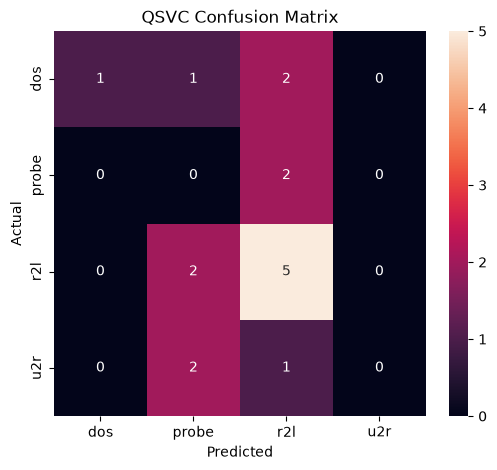

In [98]:
cm = confusion_matrix(
    quantum_results["Actual Family"],
    quantum_results["Predicted Family"],
    labels=[
        "dos",
        "probe",
        "r2l",
        "u2r"
    ]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "dos",
        "probe",
        "r2l",
        "u2r"
    ],
    yticklabels=[
        "dos",
        "probe",
        "r2l",
        "u2r"
    ]
)

plt.title(
    "QSVC Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "qsvc_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **Classical vs Quantum Comparison**

In [99]:
comparison = pd.DataFrame({

    "Method":[
        "Cosine",
        "KNN (k=5)",
        "KNN (k=1)",
        "QSVC"
    ],

    "Accuracy":[
        0.3750,
        0.4375,
        0.5625,
        q_acc
    ]
})

comparison

,Method,Accuracy
0,Cosine,0.3750
1,KNN (k=5),0.4375
2,KNN (k=1),0.5625
3,QSVC,0.3750


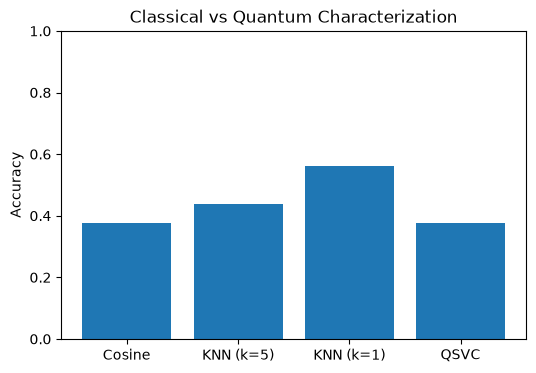

In [100]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Method"],
    comparison["Accuracy"]
)

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title(
    "Classical vs Quantum Characterization"
)

plt.savefig(
    "method_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

- Quantum attack characterization was evaluated on attack types not present in the NSL-KDD training dataset.

- The QSVC model used a Fidelity Quantum Kernel with a ZZFeatureMap to represent attack behaviour in quantum feature space.

- Results were compared against cosine similarity and KNN baselines to evaluate whether quantum-kernel similarity provides improved characterization of unseen cyber attacks.

- This experiment directly addresses the core research question of Quantinel:

### *Can quantum similarity methods better characterize previously unseen attack behaviour compared to classical similarity approaches?*